# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

# Loading the dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

In [3]:
df.sample(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
7893,7894,L55073,L,300.9,312.7,1416,43.8,112,0,0,0,0,0,0
2891,2892,L50071,L,300.6,309.6,1682,30.7,78,0,0,0,0,0,0
3788,3789,L50968,L,302.3,310.8,1511,48.1,24,0,0,0,0,0,0
8808,8809,L55988,L,297.4,308.6,1446,48.1,88,0,0,0,0,0,0
8708,8709,M23568,M,297.2,308.5,1364,54.0,43,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

# Data Pre processing

## Feature Engineering

In [5]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']*(2 * np.pi / 60)

In [6]:
df.sample(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temp_diff,Power
9055,9056,H38469,H,297.3,308.4,1864,23.1,90,0,0,0,0,0,0,11.1,4509.065104
7534,7535,L54714,L,300.0,311.2,1418,47.3,60,0,0,0,0,0,0,11.2,7023.700584
7859,7860,M22719,M,300.5,311.9,1370,44.8,20,0,0,0,0,0,0,11.4,6427.279690
641,642,L47821,L,297.9,309.5,1390,47.9,127,0,0,0,0,0,0,11.6,6972.346016
3538,3539,L50718,L,302.0,311.1,1635,36.0,23,0,0,0,0,0,0,9.1,6163.804786


## Applying Encording methods

Applied label encoding to the categorical 'type' feature

In [7]:
le = LabelEncoder()
df['Type_enc'] = le.fit_transform(df['Type'])

## Defining Features and Target variables

In [8]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temp_diff',
    'Power',
    'Type_enc'
]
X = df[features]
y = df['Machine failure']

## Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Exploratory Data Analysis (EDA)

In [11]:
X.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_diff,Power,Type_enc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,10.000630,6279.744953,1.19940
std,2.000259,1.483734,179.284096,9.968934,63.654147,1.001094,1067.418295,0.60023
min,295.300000,305.700000,1168.000000,3.800000,0.000000,7.600000,1148.440610,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,9.300000,5561.184484,1.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,9.800000,6271.027344,1.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,11.000000,7003.002724,2.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,12.100000,10469.923005,2.00000


## Class Distribution

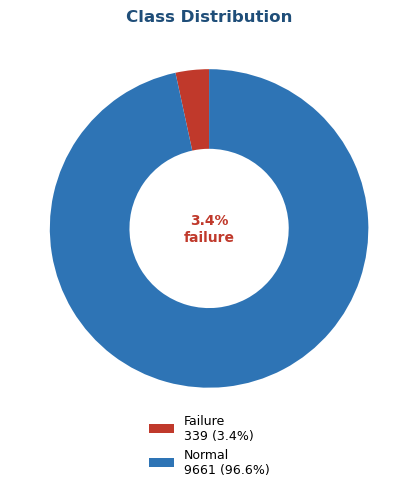

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))

vals = [df['Machine failure'].sum(), (df['Machine failure'] == 0).sum()]
labels = [
    f"Failure\n{vals[0]} ({vals[0]/len(df)*100:.1f}%)",
    f"Normal\n{vals[1]} ({vals[1]/len(df)*100:.1f}%)"
]

wedges, _ = ax.pie(vals, colors=['#C0392B', '#2E74B5'], startangle=90,
                   wedgeprops=dict(width=0.5))

ax.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
          fontsize=9, frameon=False)
ax.set_title('Class Distribution', fontweight='bold', color='#1F4E79')

centre = plt.Circle((0, 0), 0.25, color='white')
ax.add_artist(centre)
ax.text(0, 0, f'{vals[0]/len(df)*100:.1f}%\nfailure',
        ha='center', va='center', fontsize=10, fontweight='bold', color='#C0392B')

plt.tight_layout()
plt.savefig('eda_3_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Faliure Type Distribution

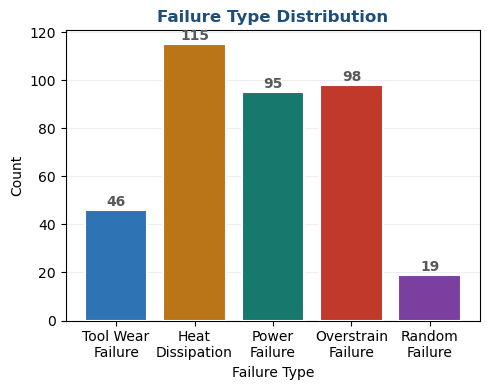

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))

fail_cols = {
    'TWF': 'Tool Wear\nFailure',
    'HDF': 'Heat\nDissipation',
    'PWF': 'Power\nFailure',
    'OSF': 'Overstrain\nFailure',
    'RNF': 'Random\nFailure'
}
counts = [df[c].sum() for c in fail_cols]

bars2 = ax.bar(list(fail_cols.values()), counts,
               color=['#2E74B5', '#BA7517', '#17786E', '#C0392B', '#7B3FA0'], edgecolor='white', linewidth=1.5, zorder=3)

for bar, cnt in zip(bars2, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#595959')

ax.set_title('Failure Type Distribution', fontweight='bold', color='#1F4E79')
ax.set_ylabel('Count')
ax.set_xlabel('Failure Type')

ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#EEEEEE', zorder=0)

plt.tight_layout()
plt.show()

## Tool Wear Distribution

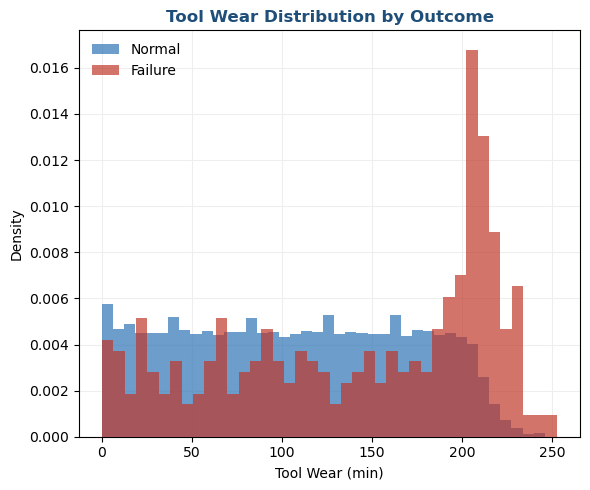

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(df[df['Machine failure'] == 0]['Tool wear [min]'],
        bins=40, alpha=0.7, color='#2E74B5', label='Normal', density=True, zorder=3)
ax.hist(df[df['Machine failure'] == 1]['Tool wear [min]'],
        bins=40, alpha=0.7, color='#C0392B', label='Failure', density=True, zorder=3)

ax.set_title('Tool Wear Distribution by Outcome', fontweight='bold', color='#1F4E79')
ax.set_xlabel('Tool Wear (min)')
ax.set_ylabel('Density')
ax.legend(frameon=False)

ax.set_axisbelow(True)
ax.grid(True, color='#EEEEEE', zorder=0)

plt.tight_layout()
plt.show()


## Torque vs Rotational Speed

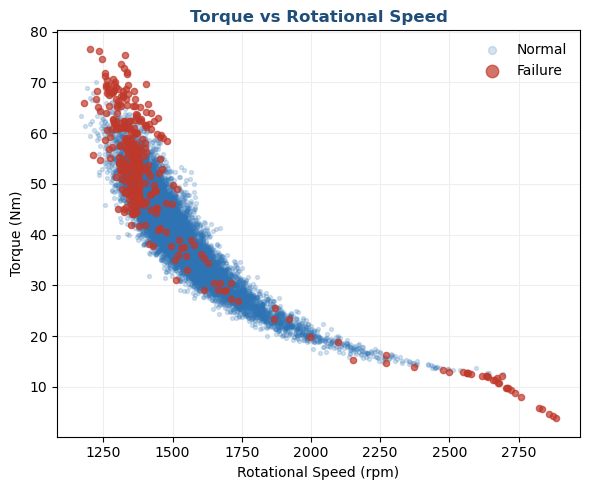

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(df[df['Machine failure'] == 0]['Rotational speed [rpm]'],
           df[df['Machine failure'] == 0]['Torque [Nm]'],
           alpha=0.2, s=8, color='#2E74B5', label='Normal', zorder=2)
ax.scatter(df[df['Machine failure'] == 1]['Rotational speed [rpm]'],
           df[df['Machine failure'] == 1]['Torque [Nm]'],
           alpha=0.7, s=20, color='#C0392B', label='Failure', zorder=3)

ax.set_title('Torque vs Rotational Speed', fontweight='bold', color='#1F4E79')
ax.set_xlabel('Rotational Speed (rpm)')
ax.set_ylabel('Torque (Nm)')
ax.legend(frameon=False, markerscale=2)

ax.set_axisbelow(True)
ax.grid(True, color='#EEEEEE', zorder=0)

plt.tight_layout()
plt.show()


## Correlation Heatmap

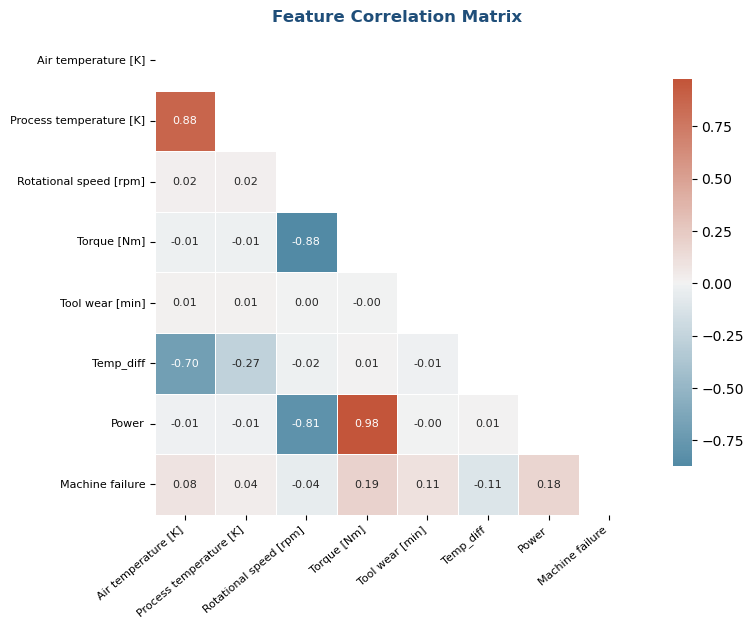

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
num_cols = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]',
    'Tool wear [min]', 'Temp_diff', 'Power', 'Machine failure'
]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, square=True,
            linewidths=0.5, annot=True, fmt='.2f', ax=ax,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', color='#1F4E79')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

axes[1].set_visible(False)

plt.tight_layout()
plt.show()



# Applying Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [20]:
print("=== LOGISTIC REGRESSION PERFORMANCE ===")
print(classification_report(y_test, y_pred_lr, target_names=['No Failure', 'Failure']))

=== LOGISTIC REGRESSION PERFORMANCE ===
              precision    recall  f1-score   support

  No Failure       1.00      0.86      0.92      1932
     Failure       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [21]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Confusion Matrix:
[[1660  272]
 [   8   60]]


# Applying Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [25]:
print("=== RANDOM FOREST PERFORMANCE ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Failure', 'Failure']))

=== RANDOM FOREST PERFORMANCE ===
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.94      0.68      0.79        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000



In [26]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix:
[[1929    3]
 [  22   46]]


# Applying XGBoost Classifier

In [27]:
from xgboost import XGBClassifier

In [28]:
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

In [29]:
xgb_model = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [30]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [31]:
print("=== XGBOOST PERFORMANCE ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No Failure', 'Failure']))

=== XGBOOST PERFORMANCE ===
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.80      0.82      0.81        68

    accuracy                           0.99      2000
   macro avg       0.90      0.91      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [32]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Confusion Matrix:
[[1918   14]
 [  12   56]]


# Model Comparison

In [33]:

 models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
 }

In [34]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, f1_score

print(f"{'Model':<20} {'AUC-ROC':>10} {'Avg Prec':>10} {'F-Recall':>10} {'F-F1':>10}")
print("--------------------------------------------------------------------")

# 2. Iterate through your trained models
for name, model in models.items():
    
    y_pred = model.predict(X_test_scaled)
    
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    auc_roc = roc_auc_score(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)
    f_recall = recall_score(y_test, y_pred)
    f_f1 = f1_score(y_test, y_pred)
    
    print(f"{name:<20} {auc_roc:>10.4f} {avg_prec:>10.4f} {f_recall:>10.4f} {f_f1:>10.4f}")

Model                   AUC-ROC   Avg Prec   F-Recall       F-F1
--------------------------------------------------------------------
Logistic Regression      0.9330     0.4733     0.8824     0.3000
Random Forest            0.9674     0.8515     0.6765     0.7863
XGBoost                  0.9780     0.8663     0.8235     0.8116


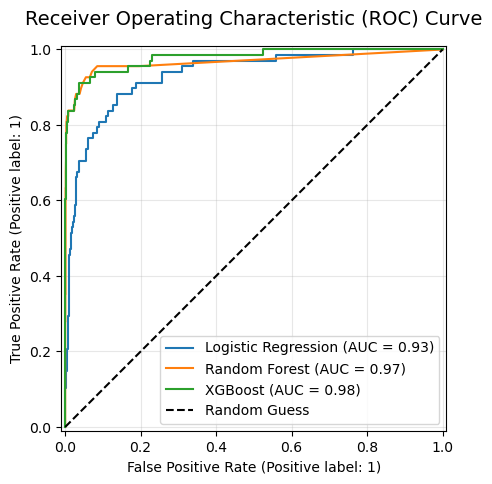

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

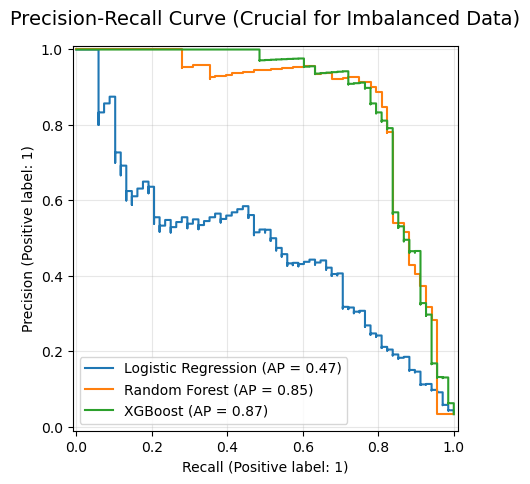

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
plt.title('Precision-Recall Curve (Crucial for Imbalanced Data)', fontsize=14, pad=15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

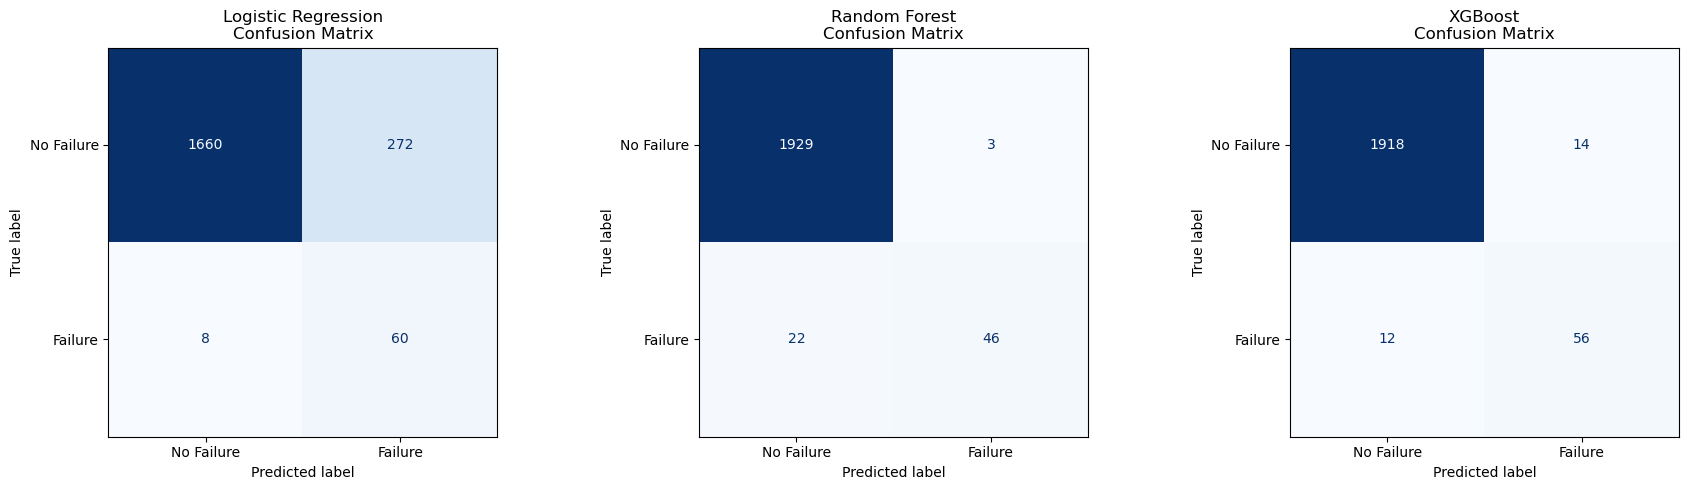

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(models.items()):
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test_scaled, y_test, 
        ax=axes[idx], cmap='Blues', colorbar=False,
        display_labels=['No Failure', 'Failure']
    )
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12)
    
plt.tight_layout()
plt.show()